In [17]:
!pip install pulp

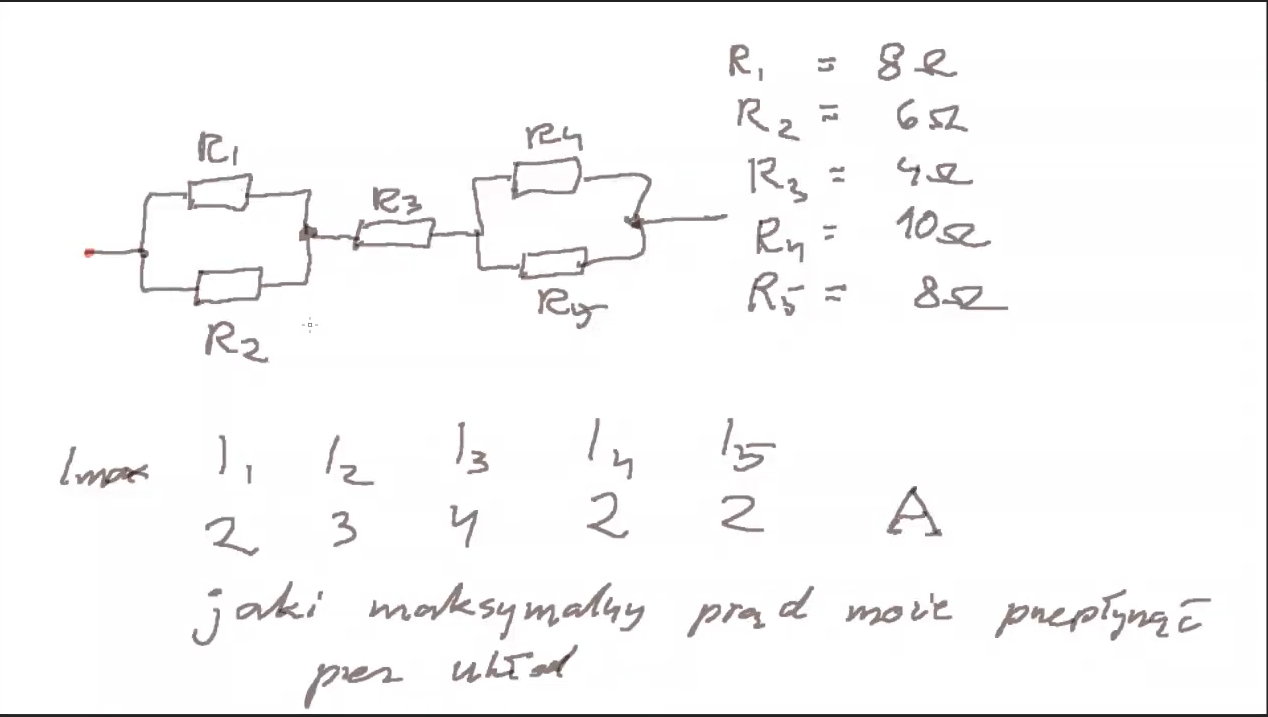

In [18]:
import pulp

In [19]:

problem = pulp.LpProblem("Max_Current_Circuit", pulp.LpMaximize)
I_max = pulp.LpVariable("I_max", lowBound=0)


R1, R2, R3, R4, R5 = 8, 6, 4, 10, 8
I1_max, I2_max, I3_max, I4_max, I5_max = 2, 3, 4, 2, 2


In [20]:
problem += I_max
problem += I_max <= I3_max, "Max_Current_R3"
problem += I_max * (R2 / (R1 + R2)) <= I1_max, "Max_Current_R1"
problem += I_max * (R1 / (R1 + R2)) <= I2_max, "Max_Current_R2"
problem += I_max * (R5 / (R4 + R5)) <= I4_max, "Max_Current_R4"
problem += I_max * (R4 / (R4 + R5)) <= I5_max, "Max_Current_R5"

problem.solve()

print("Status:", pulp.LpStatus[problem.status])
print("Maximum Current =", I_max.varValue)
print("Objective Value =", pulp.value(problem.objective))

Status: Optimal
Maximum Current = 3.6
Objective Value = 3.6
